In [46]:
import random
import math
import numpy as np

runs = []
for j in range(300):
    price_today = 300  # Reset starting price for each run
    prices = [price_today]
    for i in range(300):
        price_today = math.exp(np.random.standard_t(7) * 0.015 + 0.0005) * price_today
        prices.append(price_today)
    runs.append(prices)

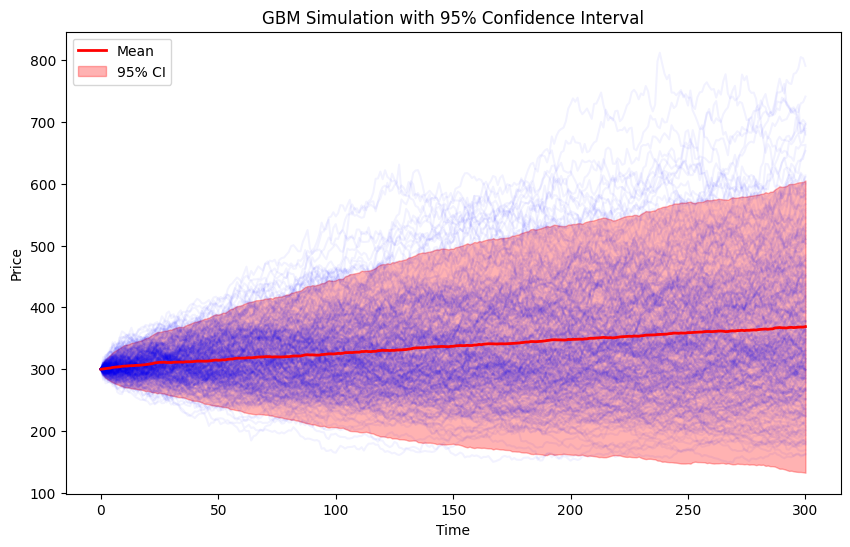

In [ ]:
import random
import math
import numpy as np

runs = []
for j in range(300):
    price_today = 300  # Reset starting price for each run
    prices = [price_today]
    for i in range(300):
        price_today = math.exp(np.random.standard_t(7) * 0.015 + 0.0005) * price_today
        prices.append(price_today)
    runs.append(prices)

# Plot all the runs like a GBM simulation plot with 95% CI
import matplotlib.pyplot as plt
import numpy as np

runs_array = np.array(runs)
mean_path = runs_array.mean(axis=0)
std_path = runs_array.std(axis=0)

# 95% CI bounds
upper_ci = mean_path + 1.96 * std_path
lower_ci = mean_path - 1.96 * std_path

plt.figure(figsize=(10, 6))

# Plot individual runs with low alpha
for run in runs:
    plt.plot(run, alpha=0.05, color='blue')

# Plot mean and CI
x = np.arange(len(mean_path))
plt.plot(x, mean_path, color='red', linewidth=2, label='Mean')
plt.fill_between(x, lower_ci, upper_ci, color='red', alpha=0.3, label='95% CI')

plt.xlabel('Time')
plt.ylabel('Price')
plt.title('GBM Simulation with 95% Confidence Interval')
plt.legend()
plt.show()

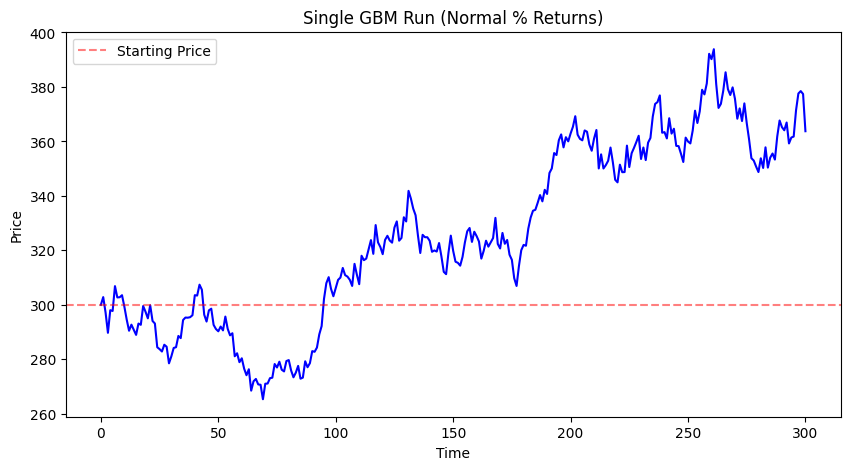

In [71]:
# Single run simulation using normal percentage returns (not log)
import random
import matplotlib.pyplot as plt

price = 300
prices = [price]

for i in range(300):
    daily_return = random.normalvariate(0.0005, 0.015)  # mean 0.05%, std 1.5%
    price = price * (1 + daily_return)  # Normal percentage change
    prices.append(price)

plt.figure(figsize=(10, 5))
plt.plot(prices, color='blue', linewidth=1.5)
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Single GBM Run (Normal % Returns)')
plt.axhline(y=300, color='red', linestyle='--', alpha=0.5, label='Starting Price')
plt.legend()
plt.show()

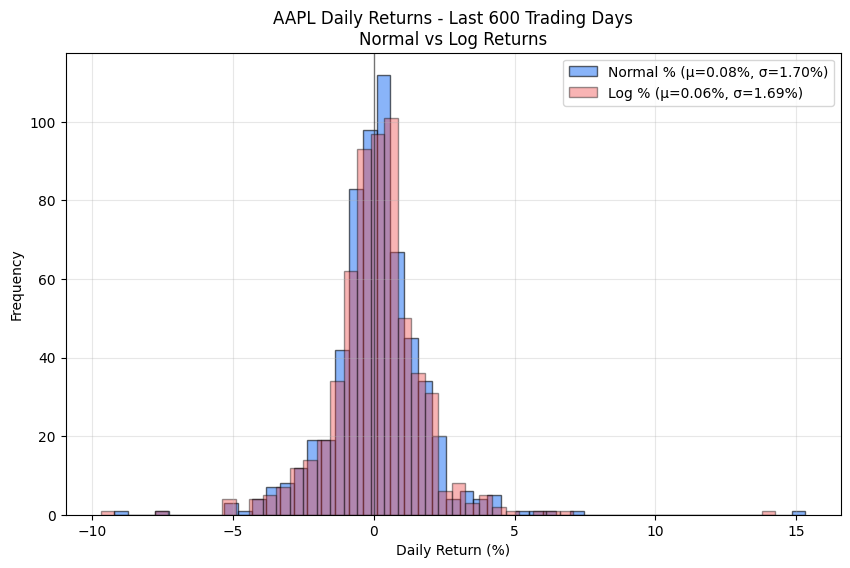

Normal %  - Mean: 0.075%, Std: 1.704%
Log %     - Mean: 0.061%, Std: 1.694%


In [76]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

# Get Apple stock data (need ~800 days to get 600 trading days of returns)
aapl = yf.download('AAPL', period='3y', progress=False)

# Calculate daily percentage returns (normal)
pct_returns = aapl['Close'].pct_change().dropna().squeeze()

# Calculate log returns
log_returns = np.log(aapl['Close'] / aapl['Close'].shift(1)).dropna().squeeze()

# Get last 600 trading days
pct_600 = pct_returns.tail(600)
log_600 = log_returns.tail(600)

# Calculate stats
mean_pct = float(pct_600.mean())
std_pct = float(pct_600.std())
mean_log = float(log_600.mean())
std_log = float(log_600.std())

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(pct_600 * 100, bins=50, edgecolor='black', alpha=0.6, color='#3b82f6', label=f'Normal % (μ={mean_pct*100:.2f}%, σ={std_pct*100:.2f}%)')
plt.hist(log_600 * 100, bins=50, edgecolor='black', alpha=0.4, color='#ef4444', label=f'Log % (μ={mean_log*100:.2f}%, σ={std_log*100:.2f}%)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.title('AAPL Daily Returns - Last 600 Trading Days\nNormal vs Log Returns')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Normal %  - Mean: {mean_pct*100:.3f}%, Std: {std_pct*100:.3f}%")
print(f"Log %     - Mean: {mean_log*100:.3f}%, Std: {std_log*100:.3f}%")